## Baseline RF Results

In [10]:
# ============================================================
# 02 Baseline Random Forest Results Analysis
# ============================================================

from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

from lif_thesis.models.baseline_rf import build_spectra_matrix

In [11]:
# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

ROOT = Path.cwd().parents[1]

DATA_PATH = ROOT / "data" / "processed" / "bacterial_samples.parquet"
RESULTS_DIR = ROOT / "results" / "baseline_rf"

METRICS_PATH = RESULTS_DIR / "metrics.json"
MODEL_PATH = RESULTS_DIR / "baseline_rf.joblib"
ENCODER_PATH = RESULTS_DIR / "label_encoder.joblib"

print("Root:", ROOT)
print("Data path:", DATA_PATH)
print("Results path:", RESULTS_DIR)

Root: c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\Automatic-Recognition-of-Microbial-Life
Data path: c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\Automatic-Recognition-of-Microbial-Life\data\processed\bacterial_samples.parquet
Results path: c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\Automatic-Recognition-of-Microbial-Life\results\baseline_rf


In [12]:
# ------------------------------------------------------------
# 2. Load data, model, metrics, and split indices
# ------------------------------------------------------------

df = pd.read_parquet(DATA_PATH)

model = joblib.load(MODEL_PATH)
label_encoder = joblib.load(ENCODER_PATH)

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

train_idx = np.load(RESULTS_DIR / "train_idx.npy")
val_idx = np.load(RESULTS_DIR / "val_idx.npy")
test_idx = np.load(RESULTS_DIR / "test_idx.npy")

print("Data shape:", df.shape)
print("Classes:", label_encoder.classes_)

Data shape: (239638, 40)
Classes: ['B. cereus' 'B. endophyticus' 'K. salsicia' 'M. luteus' 'S. huminis']


In [13]:
# ------------------------------------------------------------
# 3. Summarize split composition
# ------------------------------------------------------------

split_summary = []

for split_name, idx in {
    "train": train_idx,
    "validation": val_idx,
    "test": test_idx,
}.items():
    split_df = df.iloc[idx]

    split_summary.append({
        "split": split_name,
        "n_particles": len(split_df),
        "n_raw_files": split_df["raw_file"].nunique(),
        "n_species": split_df["species"].nunique(),
    })

split_summary_df = pd.DataFrame(split_summary)
display(split_summary_df)

for split_name, idx in {
    "train": train_idx,
    "validation": val_idx,
    "test": test_idx,
}.items():
    print(f"\n{split_name.upper()} species distribution")
    display(df.iloc[idx]["species"].value_counts(normalize=True))

,split,n_particles,n_raw_files,n_species
0,train,167747,35,5
1,validation,47926,10,5
2,test,23965,5,5



TRAIN species distribution


species
K. salsicia        0.200033
B. cereus          0.200027
S. huminis         0.200010
M. luteus          0.199974
B. endophyticus    0.199956
Name: proportion, dtype: float64


VALIDATION species distribution


species
B. cereus          0.200038
K. salsicia        0.200038
M. luteus          0.200017
S. huminis         0.199975
B. endophyticus    0.199933
Name: proportion, dtype: float64


TEST species distribution


species
B. cereus          0.200042
K. salsicia        0.200042
S. huminis         0.200000
B. endophyticus    0.199958
M. luteus          0.199958
Name: proportion, dtype: float64

In [14]:
# ------------------------------------------------------------
# 4. Compact metrics table
# ------------------------------------------------------------

rows = []

for split_name in ["train", "val", "test"]:
    m = metrics[split_name]

    rows.append({
        "split": split_name,
        "accuracy": m.get("accuracy"),
        "balanced_accuracy": m.get("balanced_accuracy"),
        "macro_f1": m.get("macro_f1"),
        "weighted_f1": m.get("weighted_f1"),
        "roc_auc": m.get("roc_auc"),
        "pr_auc": m.get("pr_auc"),
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc,pr_auc
0,train,1.000000,1.000000,1.000000,1.00000,None,None
1,val,0.620102,0.620123,0.608646,0.60863,None,None
2,test,0.620697,0.620731,0.607988,0.60796,None,None


In [15]:
# ------------------------------------------------------------
# 5. Build X/y for test set
# ------------------------------------------------------------

X = build_spectra_matrix(df, spectra_col="spectrometer")
y = label_encoder.transform(df["species"].astype(str))

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)

class_names = label_encoder.classes_.tolist()

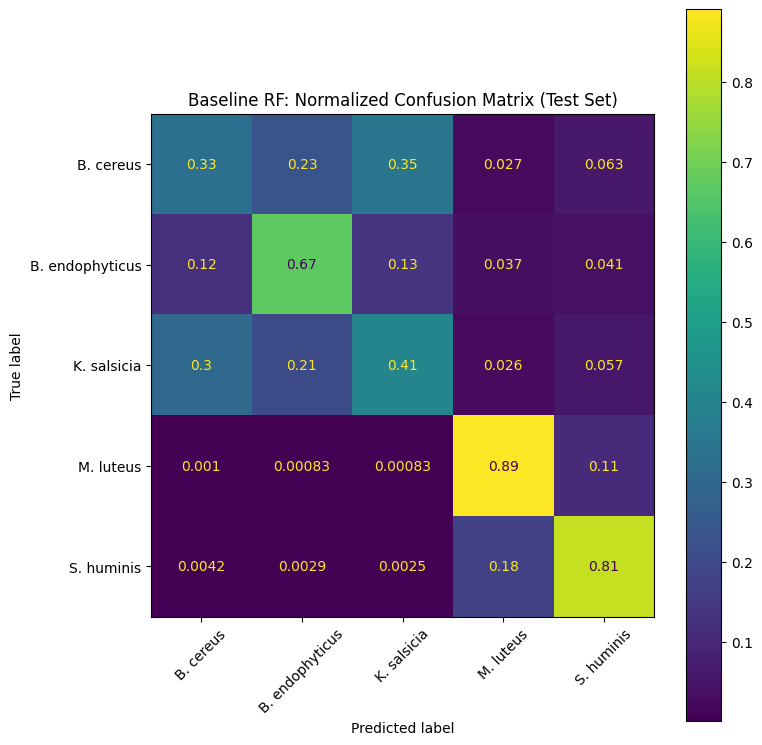

In [16]:
# ------------------------------------------------------------
# 6. Confusion matrix: test set
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=class_names,
    xticks_rotation=45,
    normalize="true",
    ax=ax,
)

ax.set_title("Baseline RF: Normalized Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [17]:
# ------------------------------------------------------------
# 7. Per-class classification report
# ------------------------------------------------------------

report = metrics["test"]["classification_report"]

report_df = (
    pd.DataFrame(report)
    .T
    .reset_index()
    .rename(columns={"index": "class"})
)

display(report_df)

,class,precision,recall,f1-score,support
0,B. cereus,0.432313,0.327076,0.372402,4794.000000
1,B. endophyticus,0.600525,0.668197,0.632556,4792.000000
2,K. salsicia,0.453315,0.405090,0.427848,4794.000000
3,M. luteus,0.769619,0.890234,0.825544,4792.000000
4,S. huminis,0.752462,0.813061,0.781588,4793.000000
5,accuracy,0.620697,0.620697,0.620697,0.620697
6,macro avg,0.601647,0.620731,0.607988,23965.000000
7,weighted avg,0.601627,0.620697,0.607960,23965.000000


In [18]:
# ------------------------------------------------------------
# 7. Per-class classification report
# ------------------------------------------------------------

report = metrics["test"]["classification_report"]

report_df = (
    pd.DataFrame(report)
    .T
    .reset_index()
    .rename(columns={"index": "class"})
)

display(report_df)

,class,precision,recall,f1-score,support
0,B. cereus,0.432313,0.327076,0.372402,4794.000000
1,B. endophyticus,0.600525,0.668197,0.632556,4792.000000
2,K. salsicia,0.453315,0.405090,0.427848,4794.000000
3,M. luteus,0.769619,0.890234,0.825544,4792.000000
4,S. huminis,0.752462,0.813061,0.781588,4793.000000
5,accuracy,0.620697,0.620697,0.620697,0.620697
6,macro avg,0.601647,0.620731,0.607988,23965.000000
7,weighted avg,0.601627,0.620697,0.607960,23965.000000


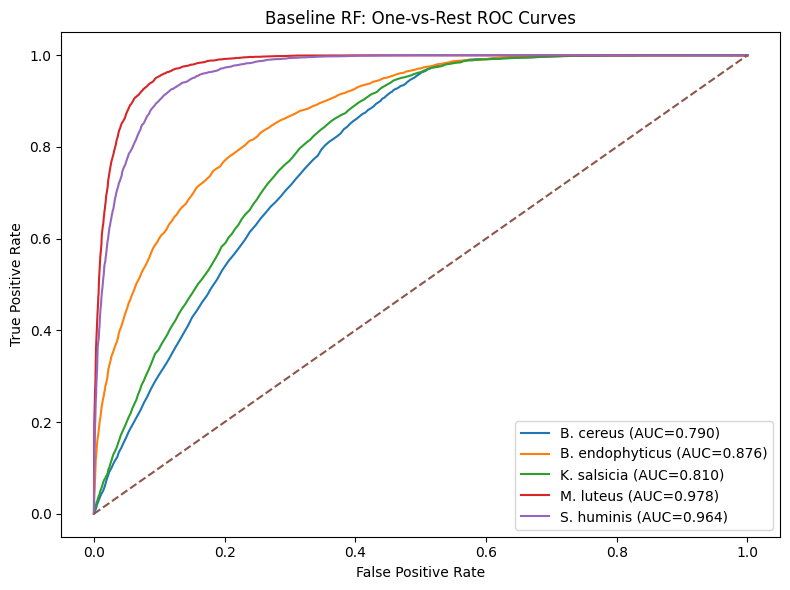

In [19]:
# ------------------------------------------------------------
# 8. One-vs-rest ROC curves
# ------------------------------------------------------------

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline RF: One-vs-Rest ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

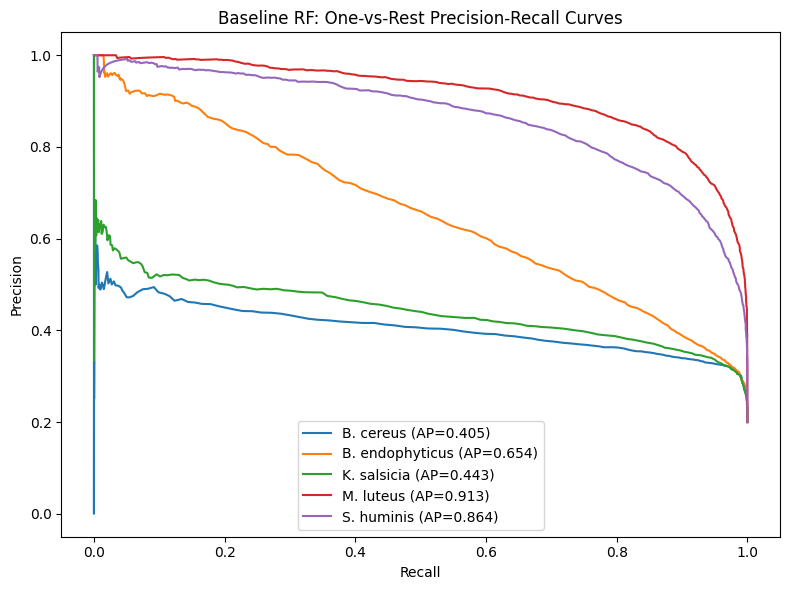

In [20]:
# ------------------------------------------------------------
# 9. One-vs-rest Precision-Recall curves
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_test_proba[:, i],
    )

    ap = average_precision_score(
        y_test_bin[:, i],
        y_test_proba[:, i],
    )

    plt.plot(recall, precision, label=f"{class_name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Baseline RF: One-vs-Rest Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

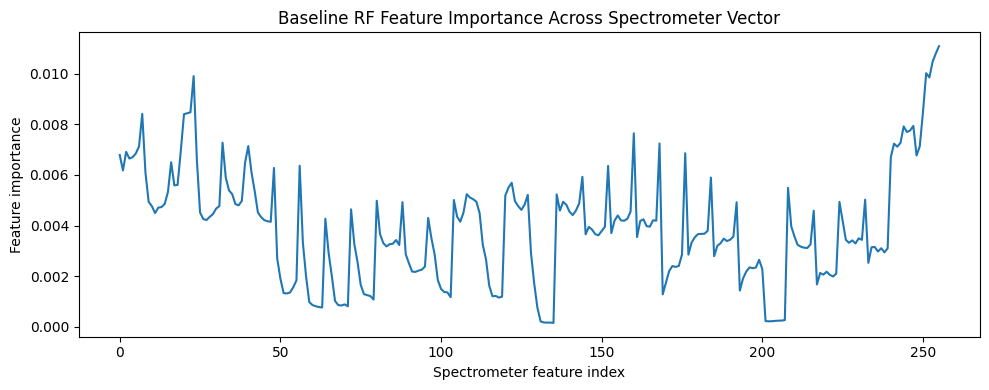

,feature_index,importance
255,255,0.011088
254,254,0.010801
253,253,0.010473
251,251,0.010021
23,23,0.009905
252,252,0.009854
250,250,0.008486
22,22,0.008476
21,21,0.008439
7,7,0.008414


In [21]:
# ------------------------------------------------------------
# 10. Feature importance across fluorescence bins
# ------------------------------------------------------------

importances = model.feature_importances_

plt.figure(figsize=(10, 4))
plt.plot(importances)
plt.xlabel("Spectrometer feature index")
plt.ylabel("Feature importance")
plt.title("Baseline RF Feature Importance Across Spectrometer Vector")
plt.tight_layout()
plt.show()

top_features = (
    pd.DataFrame({
        "feature_index": np.arange(len(importances)),
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(top_features)

,true_label,pred_label,confidence,correct
0,B. cereus,B. cereus,0.330,True
1,B. cereus,B. cereus,0.370,True
2,B. cereus,B. endophyticus,0.436,False
3,B. cereus,K. salsicia,0.300,False
4,B. cereus,K. salsicia,0.414,False


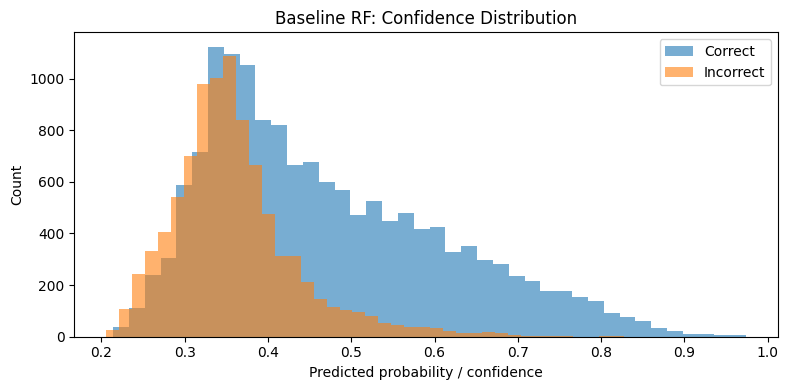

In [22]:
# ------------------------------------------------------------
# 11. Prediction confidence analysis
# ------------------------------------------------------------

test_confidence = y_test_proba.max(axis=1)
test_correct = y_test_pred == y_test

confidence_df = pd.DataFrame({
    "true_label": label_encoder.inverse_transform(y_test),
    "pred_label": label_encoder.inverse_transform(y_test_pred),
    "confidence": test_confidence,
    "correct": test_correct,
})

display(confidence_df.head())

plt.figure(figsize=(8, 4))
plt.hist(confidence_df.loc[confidence_df["correct"], "confidence"], bins=40, alpha=0.6, label="Correct")
plt.hist(confidence_df.loc[~confidence_df["correct"], "confidence"], bins=40, alpha=0.6, label="Incorrect")
plt.xlabel("Predicted probability / confidence")
plt.ylabel("Count")
plt.title("Baseline RF: Confidence Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ------------------------------------------------------------
# 12. Error analysis: most common confusions
# ------------------------------------------------------------

errors = confidence_df[~confidence_df["correct"]].copy()

confusions = (
    errors
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(confusions.head(20))

,true_label,pred_label,count
1,B. cereus,K. salsicia,1683
8,K. salsicia,B. cereus,1457
0,B. cereus,B. endophyticus,1114
9,K. salsicia,B. endophyticus,998
19,S. huminis,M. luteus,850
5,B. endophyticus,K. salsicia,643
4,B. endophyticus,B. cereus,577
15,M. luteus,S. huminis,513
3,B. cereus,S. huminis,301
11,K. salsicia,S. huminis,273


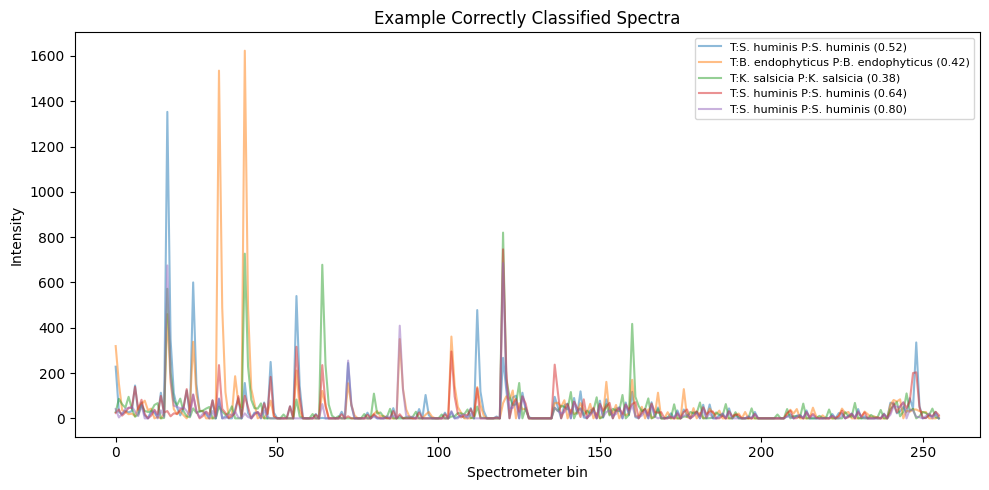

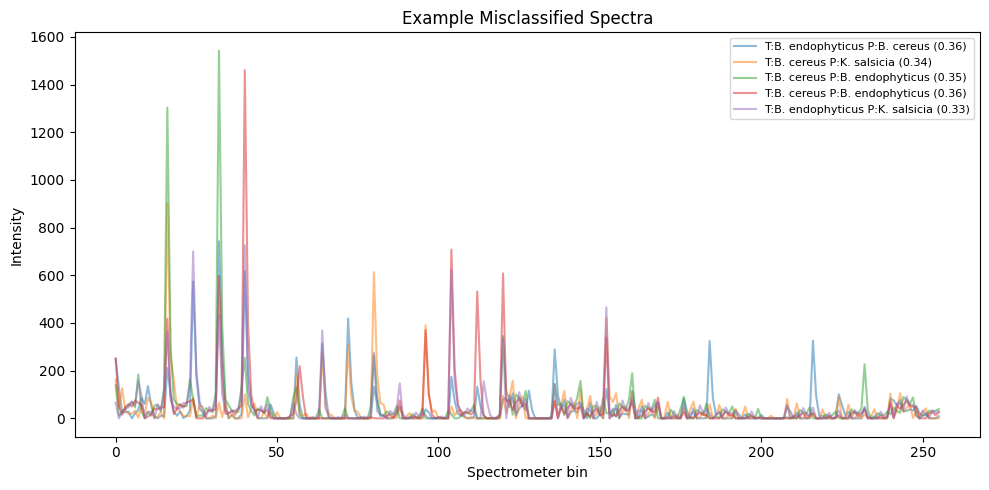

In [24]:
# ------------------------------------------------------------
# 13. Example spectra: correct vs incorrect predictions
# ------------------------------------------------------------

def plot_example_spectra(example_df, title, n=8):
    sample = example_df.sample(min(n, len(example_df)), random_state=42)

    plt.figure(figsize=(10, 5))

    for idx in sample.index:
        spectrum = np.asarray(df.iloc[test_idx[idx]]["spectrometer"])
        true_label = sample.loc[idx, "true_label"]
        pred_label = sample.loc[idx, "pred_label"]
        conf = sample.loc[idx, "confidence"]

        plt.plot(
            spectrum,
            alpha=0.5,
            label=f"T:{true_label} P:{pred_label} ({conf:.2f})",
        )

    plt.xlabel("Spectrometer bin")
    plt.ylabel("Intensity")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


correct_examples = confidence_df[confidence_df["correct"]]
incorrect_examples = confidence_df[~confidence_df["correct"]]

plot_example_spectra(
    correct_examples,
    title="Example Correctly Classified Spectra",
    n=5,
)

if len(incorrect_examples) > 0:
    plot_example_spectra(
        incorrect_examples,
        title="Example Misclassified Spectra",
        n=5,
    )
else:
    print("No incorrect examples found.")

In [25]:
# ------------------------------------------------------------
# 14. Save summary outputs for report
# ------------------------------------------------------------

OUTPUT_DIR = ROOT / "results" / "baseline_rf_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)
report_df.to_csv(OUTPUT_DIR / "classification_report_test.csv", index=False)
confusions.to_csv(OUTPUT_DIR / "test_confusions.csv", index=False)
top_features.to_csv(OUTPUT_DIR / "top_rf_features.csv", index=False)

print(f"Saved analysis outputs to: {OUTPUT_DIR}")

Saved analysis outputs to: c:\Users\chris\OneDrive\Documents\Universitat de Barcelona\Automatic-Recognition-of-Microbial-Life\results\baseline_rf_analysis
